In [1]:
# Source - https://stackoverflow.com/a
# Posted by matthiash, modified by community. See post 'Timeline' for change history
# Retrieved 2025-12-09, License - CC BY-SA 3.0

from IPython.display import HTML
HTML('''<script>
code_show_err=false; 
function code_toggle_err() {
 if (code_show_err){
 $('div.output_stderr').hide();
 } else {
 $('div.output_stderr').show();
 }
 code_show_err = !code_show_err
} 
$( document ).ready(code_toggle_err);
</script>
To toggle on/off output_stderr, click <a href="javascript:code_toggle_err()">here</a>.''')

In [2]:
from pathlib import Path
from os import environ


# IN_COLAB = False
# if "DRIVE_HOME" in environ:
  # ROOT = Path(f"{environ.get("DRIVE_HOME")}/colab/outputs/waterloo-slt-reading-group")
# else:
ROOT = Path(f"{Path.cwd().parents[1]}/outputs")
basedir = Path(f"{ROOT}/mixture/poisson3d")
# datadir = Path(f"{basedir}/data")
outputdir = Path(f"{basedir}/data")

if not outputdir.exists():
  outputdir.mkdir(exist_ok=True)
  print(f"Created {outputdir}!")

print(f"Using outputdir={outputdir}")

Using outputdir=/Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson3d/data


In [3]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd

# from sklearn_extension.mixture import PoissonMixture
from sklearn.utils import resample

from IPython.display import display, clear_output
from tqdm.notebook import tqdm

from joblib import Parallel, delayed
import multiprocessing as mp
# from plot import visualize_joint_confidence_regions
import seaborn as sns
from matplotlib.lines import Line2D
import math

default_palette = "tab10"
# Enable LaTeX rendering
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

In [10]:
dgps_file = Path(f"{outputdir}/dgp.csv")
if dgps_file.exists():  # check if this data has already been generated
  print(f"File {dgps_file} exists, skipping experiments meta!.")
else:
  if dgps_file.parent:  # create parents dir if not already
      dgps_file.parent.mkdir(parents=True, exist_ok=True)

  dsids = ["regular", "e-singular", "singular1", "singular2"]
  dgps_raw = {
      "dsid": dsids,
      "m0": np.array([15, 15, 15, 5]),
      "m1": np.array([1, 1, 1, 5]),
      "m2": np.array([5, 10, 5, 5]),
      "w0": np.array([0.50, 0.50, 1, 0.50]),
      "w1": np.array([0.25, 0.25, 0, 0.25]),
  }
  dgps_raw["w2"] = 1 - (dgps_raw["w0"]+dgps_raw["w1"])
  pd.DataFrame(dgps_raw).set_index("dsid").to_csv(dgps_file)
  print(f"File {dgps_file} created!.")

dgps = pd.read_csv(dgps_file, index_col=0).reset_index()
dgps.head()

File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson3d/data/dgp.csv created!.


,dsid,m0,m1,m2,w0,w1,w2
0,regular,15,1,5,0.5,0.25,0.25
1,e-singular,15,1,10,0.5,0.25,0.25
2,singular1,15,1,5,1.0,0.00,0.00
3,singular2,5,5,5,0.5,0.25,0.25


In [11]:
from sklearn_extensions.mixture import mixpoisson_sample

num_replications = 1000  # number of samples per sample size
regimes = [50, 250, 5000]

for dsid in dgps["dsid"].unique():
  for regime in regimes:
    obs_file = Path(
        f"{outputdir}/{dsid}-{regime}.csv"
    )  # where we are going to store observations
    if obs_file.exists():  # check if this data has already been generated
        print(f"File {obs_file} exists, skipping random samples creation!.")
    else:
        if obs_file.parent:  # create parents dir if not already
            obs_file.parent.mkdir(parents=True, exist_ok=True)
  
        results = {}
        for i in range(num_replications):
            dgp = dgps.query(f"dsid=='{dsid}'")
            mus = dgp[["m0", "m1", "m2"]].iloc[0].tolist()
            weights = dgp[["w0", "w1", "w2"]].iloc[0].tolist()
            samples = mixpoisson_sample(size=regime, weights=weights, mus=mus)
            results[f"r{i}"] = samples[0]
  
        data_df = pd.DataFrame(results)
        data_df.to_csv(obs_file, index=False)
        print(f"File {obs_file} created!.")


dsids = dgps["dsid"]
data = {}
for dsid in dsids:
  data[dsid]={}
  for regime in regimes:
    data[dsid][regime] = pd.read_csv(
        f"{outputdir}/{dsid}-{regime}.csv", index_col=0
    ).reset_index()
  
print(f"loaded {list(data.keys())} samples")

File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson3d/data/regular-50.csv created!.
File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson3d/data/regular-250.csv created!.
File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson3d/data/regular-5000.csv created!.
File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson3d/data/e-singular-50.csv created!.
File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson3d/data/e-singular-250.csv created!.
File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson3d/data/e-singular-5000.csv created!.
File /Users/ashrafahmed/workspace/waterloo-slt-reading-group/zoo/python/projects/luna/outputs/mixture/poisson3d/data/singular1-50.csv

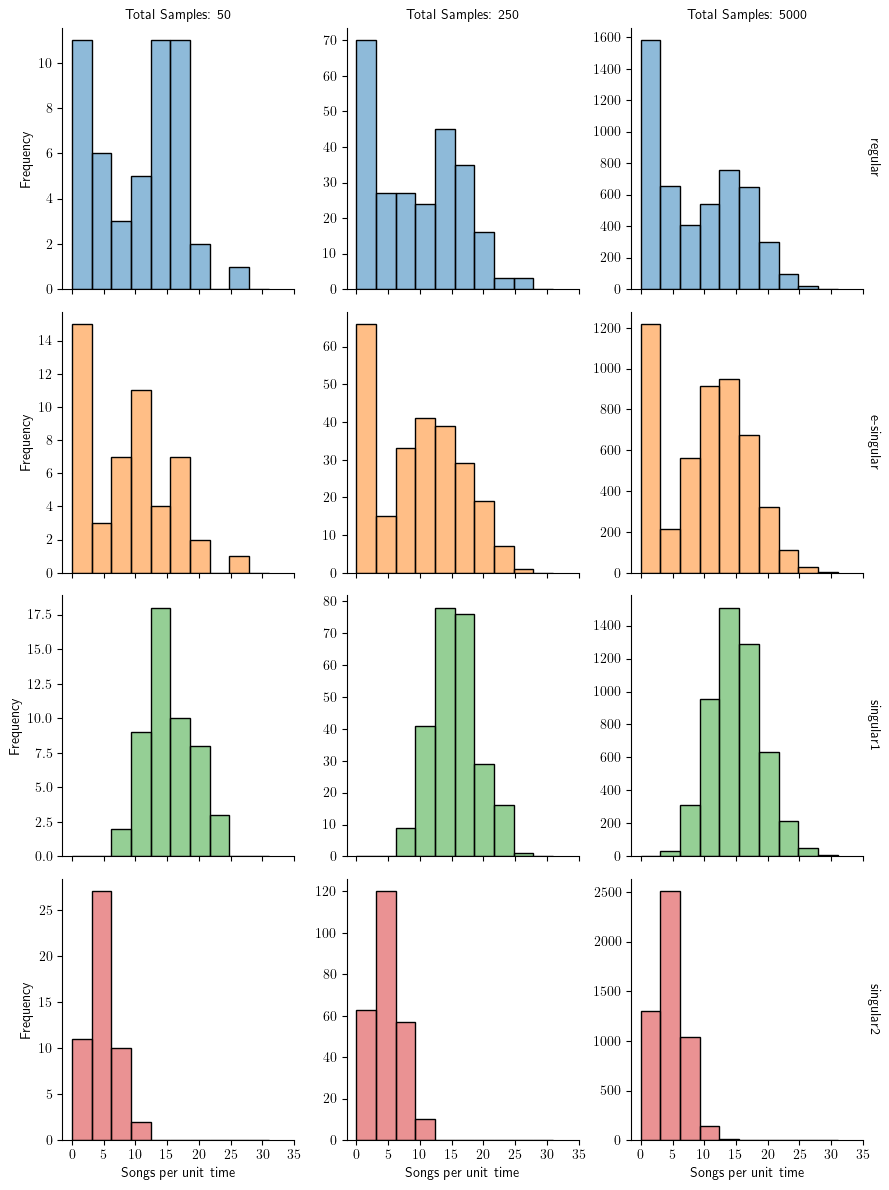

In [12]:
datasets = dgps["dsid"].unique()

# plot the data sets as different sample sizes
# we need to structure the plotting data for different sample sizes (keeping in mind that we are not regenerating the sample in each sample size)
plotdata = {"x": [], "size": [], "dsid": []} # raw data to initialize the plotting dataframe

for dsid in datasets:
    dgp = dgps.query(f"dsid == '{dsid}'")
    for ss in regimes:
        x = data[dsid][5000].iloc[:ss,1]
        plotdata["x"]=np.append(plotdata["x"], x)
        plotdata["size"]=np.append(plotdata["size"], (np.ones(ss)*ss).astype(int))
        plotdata["dsid"]=np.append(plotdata["dsid"], [dsid for i in np.ones(ss)])

plotdf = pd.DataFrame(plotdata)
plotdf = plotdf.astype({"x": int, "size": int, "dsid": str})
g=sns.displot(plotdf,
              x="x", col="size", row="dsid", hue="dsid",
              binwidth=3, height=3, facet_kws={"margin_titles": True, "sharey": False}, legend=False, palette=default_palette)

g.set_axis_labels("Songs per unit time", "Frequency")
g.set_titles(col_template="Total Samples: {col_name}", row_template=f"{{row_name}}")

for ax in g.axes.flat:
    ax.set_xticks(list(range(0, 40, 5)))

datasets_hist_file = Path(f'{outputdir}/dataset_hist.png')
if datasets_hist_file.parent: # create parents dir if not already
    datasets_hist_file.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(datasets_hist_file, dpi=300, bbox_inches='tight')
plt.show()